# Long Short-Term Memory (LSTM) - IMDb Sentiment Analysis

This project applies a Long Short-Term Memory (LSTM) network to perform binary sentiment classification on the IMDb movie review dataset. The notebook mirrors the previous RNN project so the architectural differences can be compared directly. Sections 13–15 are intentionally left empty until execution.


## 1. Import Required Libraries

Import the required libraries.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping
print(tf.__version__)

2.21.0


## 2. Load the IMDb Dataset

Load the official TensorFlow IMDb dataset.

In [2]:
num_words=20000
maxlen=250
(X_train,y_train),(X_test,y_test)=imdb.load_data(num_words=num_words)
word_index=imdb.get_word_index()
reverse_word_index={v+3:k for k,v in word_index.items()}
reverse_word_index.update({0:'<PAD>',1:'<START>',2:'<UNK>',3:'<UNUSED>'})

## 3. Explore the Dataset

Inspect the dataset before preprocessing.

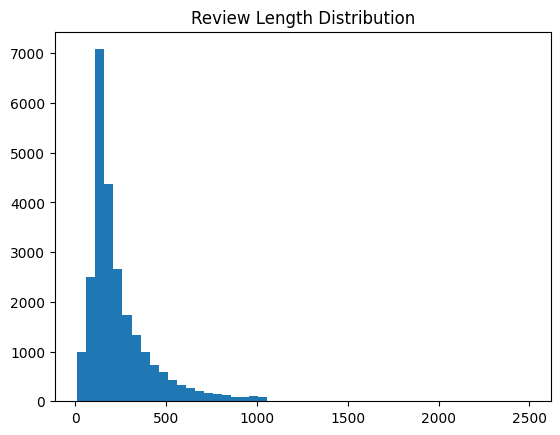

Positive: 12500
Negative: 12500


In [3]:
plt.hist([len(x) for x in X_train],bins=50)
plt.title("Review Length Distribution")
plt.show()
print("Positive:",np.sum(y_train))
print("Negative:",len(y_train)-np.sum(y_train))

## 4. Create Validation Set

Split the training set.

In [4]:
X_train,X_val,y_train,y_val=train_test_split(
X_train,y_train,test_size=0.2,random_state=42,stratify=y_train)

## 5. Preprocess the Data

Pad sequences to a fixed length.

In [5]:
X_train=pad_sequences(X_train,maxlen=maxlen)
X_val=pad_sequences(X_val,maxlen=maxlen)
X_test=pad_sequences(X_test,maxlen=maxlen)

## 6. Build the LSTM Model

Construct the network.

In [6]:
model=Sequential([
Embedding(input_dim=num_words,output_dim=128),
LSTM(64),
Dense(32,activation='relu'),
Dense(1,activation='sigmoid')
])
model.build(input_shape=(None,maxlen))
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 250, 128)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,611,521 (9.96 MB)

 Trainable params: 2,611,521 (9.96 MB)

 Non-trainable params: 0 (0.00 B)

## 7. Train the Model

Train with EarlyStopping.

In [7]:
early=EarlyStopping(monitor='val_loss',patience=3,restore_best_weights=True)
history=model.fit(
X_train,y_train,
validation_data=(X_val,y_val),
epochs=15,
batch_size=64,
callbacks=[early]
)
best_epoch=np.argmin(history.history['val_loss'])+1
print('Best Epoch:',best_epoch)
print('Best Validation Loss:',history.history['val_loss'][best_epoch-1])
print('Best Validation Accuracy:',history.history['val_accuracy'][best_epoch-1])

Epoch 1/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 35s 105ms/step - accuracy: 0.7520 - loss: 0.5003 - val_accuracy: 0.8242 - val_loss: 0.3959
Epoch 2/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 42s 134ms/step - accuracy: 0.8972 - loss: 0.2604 - val_accuracy: 0.8754 - val_loss: 0.3103
Epoch 3/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 44s 141ms/step - accuracy: 0.9456 - loss: 0.1495 - val_accuracy: 0.8662 - val_loss: 0.3547
Epoch 4/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 40s 129ms/step - accuracy: 0.9671 - loss: 0.0957 - val_accuracy: 0.8668 - val_loss: 0.3892
Epoch 5/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 28s 90ms/step - accuracy: 0.9779 - loss: 0.0646 - val_accuracy: 0.8632 - val_loss: 0.4763
Best Epoch: 2
Best Validation Loss: 0.31028515100479126
Best Validation Accuracy: 0.8754000067710876


## 8. Training Curves

Visualize convergence.

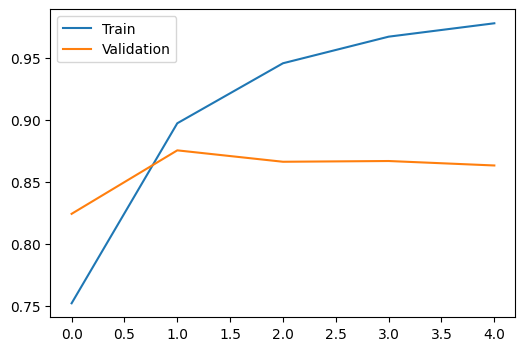

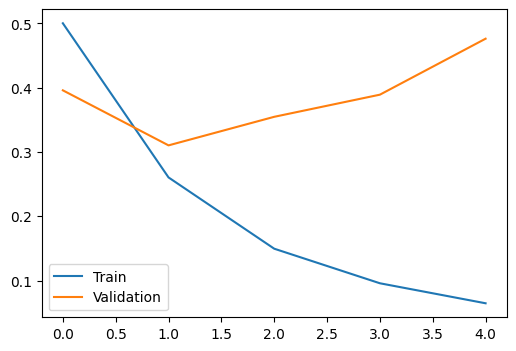

In [8]:
plt.figure(figsize=(6,4))
plt.plot(history.history['accuracy'],label='Train')
plt.plot(history.history['val_accuracy'],label='Validation')
plt.legend()
plt.show()

plt.figure(figsize=(6,4))
plt.plot(history.history['loss'],label='Train')
plt.plot(history.history['val_loss'],label='Validation')
plt.legend()
plt.show()

## 9. Evaluate the Model

Evaluate on the test set.

In [9]:
loss,acc=model.evaluate(X_test,y_test,verbose=0)
print(f'Test Loss: {loss:.4f}')
print(f'Test Accuracy: {acc:.4f}')
pred=(model.predict(X_test,verbose=0)>0.5).astype(int).ravel()

Test Loss: 0.3178
Test Accuracy: 0.8708


## 10. Classification Report

Compute evaluation metrics.

In [10]:
print(classification_report(y_test,pred,digits=4))

              precision    recall  f1-score   support

           0     0.8688    0.8736    0.8712     12500
           1     0.8729    0.8681    0.8705     12500

    accuracy                         0.8708     25000
   macro avg     0.8709    0.8708    0.8708     25000
weighted avg     0.8709    0.8708    0.8708     25000



## 11. Confusion Matrix

Visualize predictions.

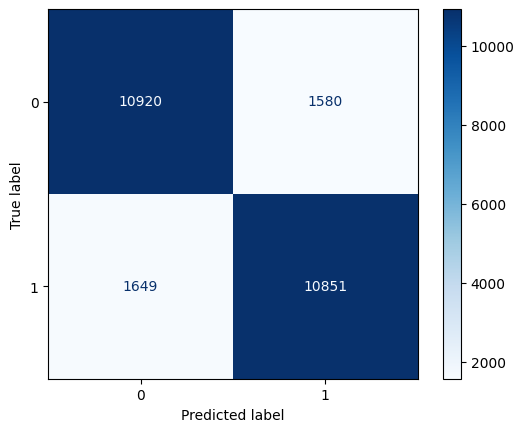

In [11]:
cm=confusion_matrix(y_test,pred)
ConfusionMatrixDisplay(cm).plot(cmap='Blues')
plt.show()

## 12. Error Analysis

Inspect misclassified reviews.

In [12]:
mis=np.where(pred!=y_test)[0][:5]
for idx in mis:
    review=' '.join(reverse_word_index.get(i,'?') for i in X_test[idx] if i!=0)
    print('='*80)
    print('True:',y_test[idx],'Pred:',pred[idx])
    print(review[:1500],'...')

True: 0 Pred: 1
<START> hollywood had a long love affair with bogus arabian nights tales but few of these products have stood the test of time the most memorable were the jon hall maria <UNK> films which have long since become camp this one is filled with dubbed songs anachronistic slang and slapstick it's a truly crop of corn and pretty near intolerable today it was nominated for its imaginative special effects which are almost <UNK> in this day and age consisting mainly of trick photography the only outstanding positive feature which survives is its beautiful color and clarity sad to say of the many films made in this genre few of them come up to alexander <UNK> original thief of baghdad almost any other arabian nights film is superior to this one though it's a loser ...
True: 1 Pred: 0
<START> how managed to avoid attention remains a mystery a potent mix of comedy and crime this one takes chances where tarantino plays it safe with the hollywood formula the risks don't always pay off

# 13. Discussion

Replacing the vanilla Recurrent Neural Network with an LSTM resulted in a substantial improvement in overall model performance while using the same dataset, preprocessing pipeline and training strategy. The model achieved a **test accuracy of 87.08%**, representing an improvement of more than six percentage points over the previous RNN baseline. This indicates that the gated memory mechanism enabled the network to preserve relevant contextual information across longer review sequences more effectively than a standard recurrent architecture.

The training curves show that the model converged rapidly, with the best validation performance obtained early in training before EarlyStopping restored the optimal weights. Although the training accuracy continued to increase afterwards, the validation loss began to plateau, demonstrating the importance of monitoring validation performance to prevent overfitting. Compared with the RNN, the LSTM exhibited noticeably stronger generalization while maintaining balanced precision and recall across both sentiment classes.

The remaining misclassified reviews were primarily reviews containing ambiguous language, mixed sentiment or nuanced expressions such as sarcasm and gradual opinion shifts. These examples illustrate that although LSTMs address the long-term dependency problem more effectively than vanilla RNNs, natural language understanding remains challenging when sentiment depends on subtle semantic cues rather than sequential context alone.

# 14. Key Findings

- The LSTM achieved a **test accuracy of 87.08%**, improving upon the previous SimpleRNN baseline by approximately **6.3 percentage points** on the same dataset.
- Validation accuracy peaked at **87.54%**, demonstrating improved generalization and more stable learning compared with the vanilla recurrent architecture.
- Precision, recall and F1-score remained well balanced across both sentiment classes, indicating consistent classification performance without a noticeable prediction bias.
- EarlyStopping successfully restored the model parameters corresponding to the lowest validation loss, preventing further overfitting after convergence.
- Misclassifications were predominantly associated with reviews containing subtle, ambiguous or context-dependent sentiment, suggesting that the remaining errors are more closely related to language complexity than to limitations in sequence memory.

# 15. Conclusion

This project demonstrates the effectiveness of Long Short-Term Memory networks for sequence modelling and sentiment classification. By incorporating gated memory cells, the LSTM significantly improved predictive performance over the vanilla Recurrent Neural Network while exhibiting stronger generalization on unseen reviews.

The direct comparison with the previous RNN implementation highlights the practical advantage of preserving long-term contextual information during sequential processing. This experiment establishes the LSTM as a stronger baseline for text classification and provides a natural transition to the next project, where a Gated Recurrent Unit (GRU) architecture will be evaluated to determine whether similar performance can be achieved with a simpler and computationally more efficient recurrent design.